# 1. Purpose and economic interpretation

N22 constructs the frozen causal realised--implied state and forward-volatility target. N23 does not fit a model, use hidden-event labels, decide whether to trade, or evaluate TEST outcomes. It translates a hypothetical volatility view into synthetic USD/JPY ATM-straddle economics, dynamically delta hedged with observed spot quotes. N24 will later connect causal information to this contract.

$$\text{raw observed ATM IV}+\text{observed USD/JPY spot path}\longrightarrow\text{synthetic delta-hedged option economics}.$$

### What the synthetic option PnL represents

This is a model-based synthetic option engine, not a fully executable historical dealer-options backtest. Historical executable option premiums, option bid/ask spreads, proprietary dealer ATM conventions, an exact intraday Bloomberg-IV timestamp, and a complete audited USD/JPY rate/forward-point history are unavailable. Observed spot bid/ask is used for hedge execution costs. The 17:00 New York timestamp is a causal decision boundary, not an observed executable option quote.

In [1]:
from pathlib import Path
import inspect
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display
PROJECT_DIR = Path.cwd().resolve()
PROCESSED = PROJECT_DIR / 'Data' / 'processed'
INTERIM = PROJECT_DIR / 'Data' / 'interim'
HOURLY = PROJECT_DIR / 'Data' / 'usdjpy_hourly_data'
FIGURES = PROJECT_DIR / 'figures'
NY_ZONE = 'America/New_York'
NY = ZoneInfo(NY_ZONE)
UNLOCK_TEST_PNL = False
DECISION_HOUR = 17
MAX_ENTRY_DELAY_HOURS = 2
MAX_EXPIRY_LEAD_HOURS = 2
MIN_HEDGE_OBSERVATIONS = 12
MAX_INTERIOR_QUOTE_GAP_HOURS = 4
R_DOMESTIC = 0.0
R_FOREIGN = 0.0
TOL = 1e-10
assert UNLOCK_TEST_PNL is False
print('N23 configuration: TEST PnL locked')

N23 configuration: TEST PnL locked


# 2. Inputs, provenance and frozen assumptions

USD/JPY is JPY per USD: JPY is domestic and USD is foreign. The baseline is one USD notional, a spot-ATM strike, ACT/365 maturity, and zero domestic and foreign rates as a short-horizon modelling simplification.

In [2]:
paths = {'n22': PROCESSED / '22_application_causal_state_panel.csv', 'daily': PROCESSED / 'usdjpy_daily_model_panel.csv', 'mid': INTERIM / 'usdjpy_hourly_mid_audited.csv', 'bid': HOURLY / 'usdjpy_hourly_bid.csv', 'ask': HOURLY / 'usdjpy_hourly_ask.csv', 'inventory': INTERIM / 'empirical_source_inventory.csv', 'coverage': INTERIM / 'empirical_coverage_summary.csv'}
assert all((path.is_file() for path in paths.values()))
n22 = pd.read_csv(paths['n22'], parse_dates=['model_day', 'next_model_day'])
assert {'model_day', 'next_model_day', 'application_stage', 'canonical_index', 'I_t'}.issubset(n22)
assert n22.model_day.is_unique and n22.model_day.is_monotonic_increasing
assert n22.application_stage.value_counts().to_dict() == {'DEVELOPMENT': 1209, 'VALIDATION': 1209, 'TEST': 1209}
assert n22.loc[n22.application_stage.eq('TEST'), ['G_next', 'C_next']].isna().all().all()
source_table = pd.DataFrame([('22_application_causal_state_panel.csv', 'chronology, stage identity and causal-model state', 'model_day, next_model_day, application_stage, I_t', 'canonical model day; 17:00 NY boundary', 'AUTHORITATIVE'), ('usdjpy_daily_model_panel.csv', 'raw Bloomberg ATM IV for pricing; model-IV consistency audit', 'implied_vol_decimal, iv_ann_var, iv_model_var', 'daily; exact quote time unresolved', 'AUTHORITATIVE'), ('usdjpy_hourly_mid_audited.csv', 'entry/expiry midpoint, delta state and frictionless benchmark', 'timestamp_parsed, mid_close', 'stored candle; quote at candle end', 'AUTHORITATIVE'), ('hourly USD/JPY bid / ask', 'observed spot hedge execution costs', 'timestamp, close', 'exact timestamp match to midpoint', 'AUTHORITATIVE')], columns=['source', 'N23 role', 'major fields', 'timestamp convention', 'status'])
display(source_table)
assumption_table = pd.DataFrame([('causal-model IV', 'weekday-normalised implied-variance state from N22'), ('option-pricing volatility', 'raw Bloomberg ATM IV in decimal units, fixed for each synthetic contract'), ('notional', '1 USD'), ('strike', 'spot ATM'), ('rates', 'r_d = r_f = 0 baseline'), ('pricing', 'Garman--Kohlhagen'), ('hedging', 'observed hourly quotes only'), ('option cost', 'unavailable; excluded'), ('spot cost', 'observed bid/ask'), ('interpolation', 'prohibited')], columns=['assumption', 'frozen convention'])
display(assumption_table)
assert 0.02 < np.sqrt(n22.I_t.dropna()).median() < 1.0

,source,N23 role,major fields,timestamp convention,status
0,22_application_causal_state_panel.csv,"chronology, stage identity and causal-model state","model_day, next_model_day, application_stage, I_t",canonical model day; 17:00 NY boundary,AUTHORITATIVE
1,usdjpy_daily_model_panel.csv,raw Bloomberg ATM IV for pricing; model-IV con...,"implied_vol_decimal, iv_ann_var, iv_model_var",daily; exact quote time unresolved,AUTHORITATIVE
2,usdjpy_hourly_mid_audited.csv,"entry/expiry midpoint, delta state and frictio...","timestamp_parsed, mid_close",stored candle; quote at candle end,AUTHORITATIVE
3,hourly USD/JPY bid / ask,observed spot hedge execution costs,"timestamp, close",exact timestamp match to midpoint,AUTHORITATIVE


,assumption,frozen convention
0,causal-model IV,weekday-normalised implied-variance state from...
1,option-pricing volatility,"raw Bloomberg ATM IV in decimal units, fixed f..."
2,notional,1 USD
3,strike,spot ATM
4,rates,r_d = r_f = 0 baseline
5,pricing,Garman--Kohlhagen
6,hedging,observed hourly quotes only
7,option cost,unavailable; excluded
8,spot cost,observed bid/ask
9,interpolation,prohibited


# 3. Timing and information boundary

For model day t, the canonical interval is:

$$[D-1,\;17{:}00\ \mathrm{NY},\;D,\;17{:}00\ \mathrm{NY}).$$

The causal state is complete at the 17:00 NY decision boundary. The first acceptable observed hourly spot quote at or after the boundary is the synthetic entry; the last acceptable observed quote before the next boundary is expiry. This boundary is not asserted to be a Bloomberg option-quote timestamp.

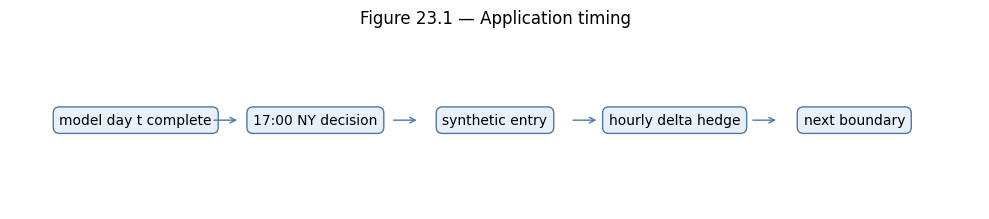

In [3]:
fig, ax = plt.subplots(figsize=(10, 2.3))
labels = ['model day t complete', '17:00 NY decision', 'synthetic entry', 'hourly delta hedge', 'next boundary']
for i, label in enumerate(labels):
    ax.text(i, 0, label, ha='center', va='center', bbox={'boxstyle': 'round,pad=.45', 'fc': '#e8f1fb', 'ec': '#4c78a8'})
    if i < 4:
        ax.annotate('', xy=(i + 0.42, 0), xytext=(i + 0.58, 0), arrowprops={'arrowstyle': '<-', 'color': '#4c78a8'})
ax.set(xlim=(-0.7, 4.7), ylim=(-0.6, 0.6))
ax.axis('off')
ax.set_title('Figure 23.1 — Application timing')
fig.tight_layout()
fig.savefig(FIGURES / '23_figure_application_timing.png', dpi=180)
plt.show()

# 4. Causal-model IV versus option-pricing IV

N22 retains the causal-model state $$I_t^{\mathrm{model}}.$$ N15 defines raw annualised implied variance and the frozen weekday-normalised state as:

$$I_t^{\mathrm{raw}}=\left(\frac{q_t}{100}\right)^2=\texttt{iv\_ann\_var}_t,$$

$$I_t^{\mathrm{model}}=\texttt{iv\_model\_var}_t=\frac{I_t^{\mathrm{raw}}}{s^{\mathrm{ALL\_TRAIN}}_{\mathrm{weekday}(t)}}.$$

Here the weekday scale is N15's frozen ALL_TRAIN training-period median weekday factor. It is used for causal modelling, not market option valuation. N23 uses raw Bloomberg ATM decimal volatility:

$$\sigma_t^{\mathrm{entry}}=\texttt{implied\_vol\_decimal}_t=\sqrt{\texttt{iv\_ann\_var}_t}.$$

`I_t_model` remains causal-model provenance; `iv_entry` is the fixed economic pricing input.

In [4]:
daily = pd.read_csv(PROCESSED / 'usdjpy_daily_model_panel.csv', parse_dates=['model_day'])
required_daily = {'model_day', 'implied_vol_decimal', 'iv_ann_var', 'iv_model_var'}
assert required_daily.issubset(daily.columns)
raw_iv = daily[['model_day', 'implied_vol_decimal', 'iv_ann_var', 'iv_model_var']].rename(columns={'implied_vol_decimal': 'iv_entry', 'iv_ann_var': 'iv_raw_variance', 'iv_model_var': 'I_t_model_daily'})
assert raw_iv.model_day.is_unique
assert np.allclose(raw_iv['iv_entry'].dropna(), np.sqrt(raw_iv.loc[raw_iv['iv_entry'].notna(), 'iv_raw_variance']), rtol=0, atol=1e-14)
n22 = n22.rename(columns={'I_t': 'I_t_model'}).merge(raw_iv, on='model_day', how='left', validate='one_to_one')
assert n22.loc[n22['application_stage'].isin(['DEVELOPMENT', 'VALIDATION']), 'iv_entry'].notna().all()
assert np.allclose(n22['I_t_model'], n22['I_t_model_daily'], rtol=0, atol=1e-14, equal_nan=True)
iv_verification = pd.DataFrame([{'max_abs_iv_entry_minus_sqrt_raw_variance': float(np.abs(n22['iv_entry'] - np.sqrt(n22['iv_raw_variance'])).max()), 'option_pricing_iv': 'RAW_BLOOMBERG_ATM_IV', 'causal_model_iv': 'WEEKDAY_NORMALISED_IV_STATE'}])
display(iv_verification)

,max_abs_iv_entry_minus_sqrt_raw_variance,option_pricing_iv,causal_model_iv
0,2.373102e-15,RAW_BLOOMBERG_ATM_IV,WEEKDAY_NORMALISED_IV_STATE


# 5. Synthetic FX option mathematics

For USD/JPY, JPY is domestic and USD is foreign. With entry midpoint $$S_0,$$ spot-ATM strike $$K=S_{0,\mathrm{mid}},$$ raw entry volatility $$\sigma,$$ maturity $$T,$$ and rates $$r_d,r_f,$$ Garman--Kohlhagen gives:

$$C=S_0e^{-r_fT}N(d_1)-Ke^{-r_dT}N(d_2),$$

$$P=Ke^{-r_dT}N(-d_2)-S_0e^{-r_fT}N(-d_1),$$

$$d_1=\frac{\log(S_0/K)+(r_d-r_f+\tfrac12\sigma^2)T}{\sigma\sqrt{T}},\qquad d_2=d_1-\sigma\sqrt{T},$$

$$V_0=C+P,\qquad\Delta_{\mathrm{straddle}}=e^{-r_fT}[2N(d_1)-1].$$

The primary baseline is $$r_d=r_f=0.$$ This is a short-horizon simplification, not a claim that historical rates were zero.

# 6. Quote-path and contract construction

The audited midpoint is checked against timestamp-matched bid and ask quotes:

$$S_t^{\mathrm{mid}}=\frac{S_t^{\mathrm{bid}}+S_t^{\mathrm{ask}}}{2}.$$

The frozen rules are retained without optimisation: entry delay at most two hours, expiry lead at most two hours, at least twelve hedge observations, and no interior observed-quote gap above four hours. There is no interpolation or forward filling.

# 7. Delta-hedging cash ledger

For position sign $$s=+1$$ for long and $$s=-1$$ for short, the entry premium cash flow is $$CF_0^{\mathrm{option}}=-sV_0.$$ The target USD hedge and trade at time j are:

$$H_j=-s\Delta_j,\qquad u_j=H_j-H_{j-1}.$$

With observed bid/ask execution price $$X_j,$$ the spot cash flow is:

$$CF_j^{\mathrm{spot}}=-u_jX_j.$$

At expiry, $$V_T=|S_T-K|$$ and the remaining hedge is explicitly unwound. Mid execution uses the midpoint; bid/ask execution uses the observed ask for purchases and bid for sales. Normalised PnL is $$\pi^{\mathrm{norm}}=\Pi/V_0.$$

In [5]:
mid = pd.read_csv(paths['mid'])
mid['source_time'] = pd.to_datetime(mid['timestamp_parsed'], utc=True)
mid['mid'] = pd.to_numeric(mid['mid_close'], errors='coerce')
bid = pd.read_csv(paths['bid'], usecols=['timestamp', 'close']).rename(columns={'close': 'bid'})
ask = pd.read_csv(paths['ask'], usecols=['timestamp', 'close']).rename(columns={'close': 'ask'})
for frame in [bid, ask]:
    frame['source_time'] = pd.to_datetime(frame.pop('timestamp'), utc=True)
quotes = mid[['source_time', 'mid']].merge(bid, on='source_time', how='left', validate='one_to_one').merge(ask, on='source_time', how='left', validate='one_to_one')
quotes['bid'] = pd.to_numeric(quotes['bid'], errors='coerce')
quotes['ask'] = pd.to_numeric(quotes['ask'], errors='coerce')
quotes['timestamp'] = quotes['source_time'] + pd.Timedelta(hours=1)
quotes['valid'] = quotes[['mid', 'bid', 'ask']].notna().all(axis=1) & quotes['mid'].gt(0) & quotes['bid'].gt(0) & quotes['ask'].ge(quotes['bid'])
quotes = quotes.sort_values('timestamp').reset_index(drop=True)
mid_error = np.abs(quotes.loc[quotes.valid, 'mid'] - (quotes.loc[quotes.valid, 'bid'] + quotes.loc[quotes.valid, 'ask']) / 2).max()
assert mid_error < 1e-10 and quotes.timestamp.is_unique
test_start = n22.loc[n22.application_stage.eq('TEST'), 'model_day'].min()
test_boundary = pd.Timestamp(test_start).tz_localize(NY_ZONE).replace(hour=DECISION_HOUR).tz_convert('UTC')
pretest_quotes = quotes.loc[quotes.timestamp.lt(test_boundary)].copy()
display(pd.DataFrame([{'hourly_rows': len(quotes), 'pretest_rows': len(pretest_quotes), 'maximum_midpoint_error': mid_error, 'interpolation_used': False}]))

def boundary(day):
    return pd.Timestamp(day).tz_localize(NY_ZONE).replace(hour=DECISION_HOUR).tz_convert('UTC')

def price(spot, strike, tau, sigma, rd=R_DOMESTIC, rf=R_FOREIGN):
    if min(spot, strike, tau, sigma) <= 0:
        raise ValueError('positive pricing inputs required')
    root_tau = math.sqrt(tau)
    d1 = (math.log(spot / strike) + (rd - rf + 0.5 * sigma ** 2) * tau) / (sigma * root_tau)
    d2 = d1 - sigma * root_tau
    foreign_discount = math.exp(-rf * tau)
    domestic_discount = math.exp(-rd * tau)
    call = spot * foreign_discount * norm.cdf(d1) - strike * domestic_discount * norm.cdf(d2)
    put = strike * domestic_discount * norm.cdf(-d2) - spot * foreign_discount * norm.cdf(-d1)
    return (call, put, d1)

def delta(spot, strike, tau, sigma, rd=R_DOMESTIC, rf=R_FOREIGN):
    """Return the Garman--Kohlhagen spot delta of one long straddle."""
    _, _, d1 = price(spot, strike, tau, sigma, rd, rf)
    foreign_discount_factor = math.exp(-rf * tau)
    return foreign_discount_factor * (2 * norm.cdf(d1) - 1)

def select_entry(b, q):
    x = q.loc[q.valid & q.timestamp.ge(b) & q.timestamp.le(b + pd.Timedelta(hours=MAX_ENTRY_DELAY_HOURS))]
    return None if x.empty else x.iloc[0]

def select_expiry(b, q):
    x = q.loc[q.valid & q.timestamp.le(b) & q.timestamp.ge(b - pd.Timedelta(hours=MAX_EXPIRY_LEAD_HOURS))]
    return None if x.empty else x.iloc[-1]

def hedge(path, strike, sigma, sign):
    entry, expiry = (path.iloc[0], path.iloc[-1])
    tau = (expiry.timestamp - entry.timestamp).total_seconds() / (365 * 24 * 3600)
    call, put, _ = price(entry.mid, strike, tau, sigma)
    holding = 0.0
    rows = []
    for i, row in path.iloc[:-1].iterrows():
        rem = (expiry.timestamp - row.timestamp).total_seconds() / (365 * 24 * 3600)
        target = -sign * delta(row.mid, strike, rem, sigma, R_DOMESTIC, R_FOREIGN)
        trade = target - holding
        px = row.ask if trade > 0 else row.bid if trade < 0 else row.mid
        rows.append((row.timestamp, 'entry_hedge' if i == 0 else 'interior_rebalance', row.bid, row.ask, row.mid, rem, sigma, delta(row.mid, strike, rem, sigma, R_DOMESTIC, R_FOREIGN), target, holding, trade, px, -trade * px, -trade * row.mid))
        holding = target
    trade = -holding
    px = expiry.ask if trade > 0 else expiry.bid if trade < 0 else expiry.mid
    rows.append((expiry.timestamp, 'terminal_unwind', expiry.bid, expiry.ask, expiry.mid, 0.0, sigma, np.nan, 0.0, holding, trade, px, -trade * px, -trade * expiry.mid))
    ledger = pd.DataFrame(rows, columns=['timestamp', 'transaction_type', 'spot_bid', 'spot_ask', 'spot_mid', 'remaining_maturity_years', 'contract_iv', 'straddle_delta', 'target_usd_hedge', 'previous_usd_hedge', 'usd_hedge_trade', 'execution_price', 'jpy_cashflow_bidask', 'jpy_cashflow_mid'])
    payoff = abs(expiry.mid - strike)
    hmid = ledger.jpy_cashflow_mid.sum()
    hba = ledger.jpy_cashflow_bidask.sum()
    pmid = -sign * (call + put) + sign * payoff + hmid
    pba = -sign * (call + put) + sign * payoff + hba
    return ({'call_premium': call, 'put_premium': put, 'straddle_premium': call + put, 'maturity_years': tau, 'terminal_spot': expiry.mid, 'option_payoff': payoff, 'pnl_mid': pmid, 'pnl_bidask': pba, 'hedge_pnl_mid': hmid, 'hedge_pnl_bidask': hba, 'spot_transaction_cost': pmid - pba, 'turnover': ledger.usd_hedge_trade.abs().sum()}, ledger)

,hourly_rows,pretest_rows,maximum_midpoint_error,interpolation_used
0,149842,120988,2.842171e-14,False


# 8. Mechanical unit tests

The deterministic tests verify non-trivial put--call parity, expiry payoffs, general and zero-rate FX delta, long--short mid symmetry, bid/ask cost direction, hedge timing, fixed IV, no future IV, and source-timestamp/no-interpolation conditions. Every PASS is calculated from an error or logical condition.

In [6]:
unit_path = pd.DataFrame({'timestamp': pd.to_datetime(['2025-01-06 17:00Z', '2025-01-06 20:00Z', '2025-01-07 14:00Z', '2025-01-07 17:00Z'], utc=True), 'mid': [100.0, 101.0, 99.5, 100.5]})
unit_path['bid'] = unit_path['mid'] - 0.01
unit_path['ask'] = unit_path['mid'] + 0.01
spot, strike, tau, sigma, rd, rf = (110.0, 107.0, 0.5, 0.15, 0.04, 0.01)
call, put, d1 = price(spot, strike, tau, sigma, rd, rf)
parity_error = abs(call - put - (spot * math.exp(-rf * tau) - strike * math.exp(-rd * tau)))
call_payoff = max(103.0 - 100.0, 0.0)
put_payoff = max(100.0 - 103.0, 0.0)
call_payoff_error = abs(call_payoff - 3.0)
put_payoff_error = abs(put_payoff - 0.0)
straddle_payoff_error = abs(call_payoff + put_payoff - abs(103.0 - 100.0))
long_result, long_ledger = hedge(unit_path, 100.0, 0.12, 1.0)
short_result, short_ledger = hedge(unit_path, 100.0, 0.12, -1.0)
general_delta_error = abs(delta(spot, strike, tau, sigma, rd, rf) - math.exp(-rf * tau) * (2 * norm.cdf(d1) - 1))
zero_delta_error = abs(delta(spot, strike, tau, sigma, 0.0, 0.0) - (2 * norm.cdf(price(spot, strike, tau, sigma)[2]) - 1))
symmetry_error = abs(long_result['pnl_mid'] + short_result['pnl_mid'])
cost_floor = min(long_result['spot_transaction_cost'], short_result['spot_transaction_cost'])
timing_ok = long_ledger.iloc[:-1]['timestamp'].lt(unit_path['timestamp'].iloc[-1]).all() and long_ledger.iloc[-1]['timestamp'] == unit_path['timestamp'].iloc[-1]
no_interpolation_ok = set(long_ledger['timestamp']).issubset(set(unit_path['timestamp']))
fixed_iv_error = float(long_ledger['contract_iv'].max() - long_ledger['contract_iv'].min())
hedge_parameters = set(inspect.signature(hedge).parameters)
forbidden_future_iv_inputs = {'iv_path', 'daily_iv', 'future_iv', 'I_t_model', 'n22'}
no_future_iv_ok = 'sigma' in hedge_parameters and hedge_parameters.isdisjoint(forbidden_future_iv_inputs) and np.allclose(long_ledger['contract_iv'], 0.12, rtol=0, atol=1e-14)
unit_tests = pd.DataFrame([('Non-trivial put-call parity', parity_error, 1e-12, parity_error <= 1e-12), ('Call expiry payoff', call_payoff_error, 1e-12, call_payoff_error <= 1e-12), ('Put expiry payoff', put_payoff_error, 1e-12, put_payoff_error <= 1e-12), ('Straddle expiry payoff', straddle_payoff_error, 1e-12, straddle_payoff_error <= 1e-12), ('Positive premium', call + put, 0.0, call + put > 0), ('General FX delta', general_delta_error, 1e-12, general_delta_error <= 1e-12), ('Zero-rate delta reduction', zero_delta_error, 1e-12, zero_delta_error <= 1e-12), ('Mid long-short symmetry', symmetry_error, 1e-12, symmetry_error <= 1e-12), ('Bid/ask cost non-negative', cost_floor, -1e-12, cost_floor >= -1e-12), ('Hedge timing', float(not timing_ok), 0.0, timing_ok), ('Fixed raw contract IV', fixed_iv_error, 1e-14, fixed_iv_error <= 1e-14), ('No future IV input', float(not no_future_iv_ok), 0.0, no_future_iv_ok), ('No interpolation', float(not no_interpolation_ok), 0.0, no_interpolation_ok)], columns=['test', 'error_or_diagnostic', 'tolerance', 'passed'])
display(unit_tests)
assert unit_tests['passed'].all()

,test,error_or_diagnostic,tolerance,passed
0,Non-trivial put-call parity,7.105427e-15,1.000000e-12,True
1,Call expiry payoff,0.000000e+00,1.000000e-12,True
2,Put expiry payoff,0.000000e+00,1.000000e-12,True
3,Straddle expiry payoff,0.000000e+00,1.000000e-12,True
4,Positive premium,9.787457e+00,0.000000e+00,True
5,General FX delta,0.000000e+00,1.000000e-12,True
6,Zero-rate delta reduction,0.000000e+00,1.000000e-12,True
7,Mid long-short symmetry,0.000000e+00,1.000000e-12,True
8,Bid/ask cost non-negative,3.772283e-02,-1.000000e-12,True
9,Hedge timing,0.000000e+00,0.000000e+00,True


### Production contract construction

After the mechanical tests pass, the same frozen builder constructs every eligible DEVELOPMENT and VALIDATION contract. It contains no hidden-event inputs and does not reselect any methodology.

In [7]:
def blank(row):
    d = {'model_day': row.model_day, 'next_model_day': row.next_model_day, 'application_stage': row.application_stage, 'canonical_index': row.canonical_index, 'I_t_model': row.I_t_model, 'iv_raw_variance': row.iv_raw_variance, 'iv_entry': row.iv_entry, 'decision_boundary': boundary(row.model_day), 'scheduled_expiry_boundary': boundary(row.next_model_day), 'actual_entry_timestamp': pd.NaT, 'actual_expiry_timestamp': pd.NaT, 'entry_delay_hours': np.nan, 'expiry_lead_hours': np.nan, 'maturity_years': np.nan, 'spot_entry_bid': np.nan, 'spot_entry_ask': np.nan, 'spot_entry_mid': np.nan, 'strike': np.nan, 'call_premium': np.nan, 'put_premium': np.nan, 'straddle_premium': np.nan, 'terminal_spot': np.nan, 'option_payoff': np.nan, 'n_hedge_observations': np.nan, 'max_quote_gap_hours': np.nan, 'entry_available': False, 'expiry_available': False, 'hedge_path_available': False, 'contract_complete': False, 'exclusion_reason': '', 'pnl_unlocked': False, 'option_pricing_type': 'SYNTHETIC_GARMAN_KOHLHAGEN', 'rates_assumption': 'ZERO_DOMESTIC_AND_FOREIGN', 'strike_convention': 'SPOT_ATM', 'hedge_volatility_convention': 'ENTRY_RAW_ATM_IV_FIXED', 'option_pricing_iv': 'RAW_BLOOMBERG_ATM_IV', 'causal_model_iv': 'WEEKDAY_NORMALISED_IV_STATE'}
    for side in ['long', 'short']:
        for metric in ['pnl_mid', 'pnl_bidask', 'pnl_norm_mid', 'pnl_norm_bidask', 'spot_transaction_cost', 'hedge_turnover', 'hedge_pnl_mid', 'hedge_pnl_bidask']:
            d[f'{side}_{metric}'] = np.nan
    return d

def build(row):
    d = blank(row)
    if row.application_stage == 'TEST' and (not UNLOCK_TEST_PNL):
        d['exclusion_reason'] = 'TEST_PNL_LOCKED'
        return (d, [])
    if not UNLOCK_TEST_PNL and row.next_model_day >= test_start:
        d['exclusion_reason'] = 'TEST_PNL_LOCKED'
        return (d, [])
    if not np.isfinite(row.iv_entry) or row.iv_entry <= 0:
        d['exclusion_reason'] = 'MISSING_IV'
        return (d, [])
    q = quotes if UNLOCK_TEST_PNL else pretest_quotes
    e = select_entry(d['decision_boundary'], q)
    if e is None:
        d['exclusion_reason'] = 'NO_ENTRY_QUOTE'
        return (d, [])
    d.update(entry_available=True, actual_entry_timestamp=e.timestamp, entry_delay_hours=(e.timestamp - d['decision_boundary']).total_seconds() / 3600)
    x = select_expiry(d['scheduled_expiry_boundary'], q)
    if x is None:
        d['exclusion_reason'] = 'NO_EXPIRY_QUOTE'
        return (d, [])
    d.update(expiry_available=True, actual_expiry_timestamp=x.timestamp, expiry_lead_hours=(d['scheduled_expiry_boundary'] - x.timestamp).total_seconds() / 3600)
    path = q.loc[q.valid & q.timestamp.between(e.timestamp, x.timestamp), ['timestamp', 'mid', 'bid', 'ask']].reset_index(drop=True)
    gaps = path.timestamp.diff().dt.total_seconds().div(3600)
    d['n_hedge_observations'] = len(path)
    d['max_quote_gap_hours'] = gaps.iloc[1:].max()
    if len(path) < MIN_HEDGE_OBSERVATIONS:
        d['exclusion_reason'] = 'INSUFFICIENT_HEDGE_OBSERVATIONS'
        return (d, [])
    if d['max_quote_gap_hours'] > MAX_INTERIOR_QUOTE_GAP_HOURS:
        d['exclusion_reason'] = 'INTERIOR_QUOTE_GAP_TOO_LARGE'
        return (d, [])
    sigma = row.iv_entry
    K = e.mid
    long, lled = hedge(path, K, sigma, 1.0)
    short, sled = hedge(path, K, sigma, -1.0)
    if long['straddle_premium'] <= 0:
        d['exclusion_reason'] = 'INVALID_PREMIUM'
        return (d, [])
    d.update(hedge_path_available=True, contract_complete=True, pnl_unlocked=True, actual_expiry_timestamp=x.timestamp, maturity_years=long['maturity_years'], spot_entry_bid=e.bid, spot_entry_ask=e.ask, spot_entry_mid=e.mid, strike=K, iv_entry=sigma, call_premium=long['call_premium'], put_premium=long['put_premium'], straddle_premium=long['straddle_premium'], terminal_spot=long['terminal_spot'], option_payoff=long['option_payoff'])
    for side, res in [('long', long), ('short', short)]:
        d[f'{side}_pnl_mid'] = res['pnl_mid']
        d[f'{side}_pnl_bidask'] = res['pnl_bidask']
        d[f'{side}_pnl_norm_mid'] = res['pnl_mid'] / long['straddle_premium']
        d[f'{side}_pnl_norm_bidask'] = res['pnl_bidask'] / long['straddle_premium']
        d[f'{side}_spot_transaction_cost'] = res['spot_transaction_cost']
        d[f'{side}_hedge_turnover'] = res['turnover']
        d[f'{side}_hedge_pnl_mid'] = res['hedge_pnl_mid']
        d[f'{side}_hedge_pnl_bidask'] = res['hedge_pnl_bidask']
    ledgers = []
    for name, ledger in [('LONG', lled), ('SHORT', sled)]:
        z = ledger.copy()
        z['model_day'] = row.model_day
        z['application_stage'] = row.application_stage
        z['position_side'] = name
        ledgers.append(z)
    return (d, ledgers)
records = []
ledgers = []
for row in n22[['model_day', 'next_model_day', 'application_stage', 'canonical_index', 'I_t_model', 'iv_raw_variance', 'iv_entry']].itertuples(index=False):
    record, items = build(row)
    records.append(record)
    ledgers.extend(items)
panel = pd.DataFrame(records).sort_values('canonical_index').reset_index(drop=True)
ledger = pd.concat(ledgers, ignore_index=True) if ledgers else pd.DataFrame()

# 9. DEVELOPMENT / VALIDATION contract coverage

The builder mechanically initialises the contract record; honours the TEST lock; validates raw entry IV; selects entry and expiry; builds an observed quote path; applies fixed quality rules; sets $$K=S_{0,\mathrm{mid}};$$ prices; hedges long and short; and populates the output fields. Coverage is a path-quality diagnostic, not a PnL optimisation.

,application_stage,n_n22_rows,entry_available,expiry_available,hedge_path_available,contract_complete,median_entry_delay_hours,median_expiry_lead_hours,median_hedge_observations,maximum_observed_quote_gap_hours,incomplete
0,DEVELOPMENT,1209,1207,1203,1048,1048,0.0,0.0,25.0,50.0,161
1,VALIDATION,1209,1206,1198,961,961,0.0,0.0,25.0,50.0,248


,application_stage,exclusion_reason,n
0,DEVELOPMENT,INTERIOR_QUOTE_GAP_TOO_LARGE,155
1,DEVELOPMENT,NO_ENTRY_QUOTE,2
2,DEVELOPMENT,NO_EXPIRY_QUOTE,4
3,VALIDATION,INTERIOR_QUOTE_GAP_TOO_LARGE,237
4,VALIDATION,NO_ENTRY_QUOTE,2
5,VALIDATION,NO_EXPIRY_QUOTE,8
6,VALIDATION,TEST_PNL_LOCKED,1


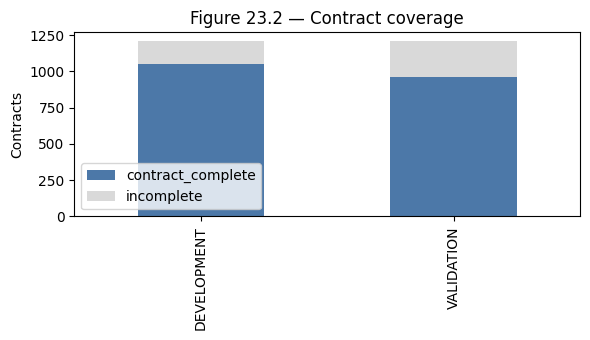

In [8]:
pre = panel.loc[panel.application_stage.isin(['DEVELOPMENT', 'VALIDATION'])].copy()
coverage = pre.groupby('application_stage', as_index=False).agg(n_n22_rows=('model_day', 'size'), entry_available=('entry_available', 'sum'), expiry_available=('expiry_available', 'sum'), hedge_path_available=('hedge_path_available', 'sum'), contract_complete=('contract_complete', 'sum'), median_entry_delay_hours=('entry_delay_hours', 'median'), median_expiry_lead_hours=('expiry_lead_hours', 'median'), median_hedge_observations=('n_hedge_observations', 'median'), maximum_observed_quote_gap_hours=('max_quote_gap_hours', 'max'))
coverage['incomplete'] = coverage.n_n22_rows - coverage.contract_complete
display(coverage)
exclusions = pre.loc[~pre.contract_complete].groupby(['application_stage', 'exclusion_reason'], as_index=False).size().rename(columns={'size': 'n'})
display(exclusions)
fig, ax = plt.subplots(figsize=(6, 3.5))
coverage.set_index('application_stage')[['contract_complete', 'incomplete']].plot(kind='bar', stacked=True, ax=ax, color=['#4c78a8', '#d9d9d9'])
ax.set(xlabel='', ylabel='Contracts', title='Figure 23.2 — Contract coverage')
fig.tight_layout()
fig.savefig(FIGURES / '23_figure_contract_coverage.png', dpi=180)
plt.show()
complete = pre.loc[pre.contract_complete].copy()

# 10. Example contract audit

One complete contract is shown below with the first and last hedge transactions. Every timestamp comes from an observed hourly quote; the contract IV remains fixed from entry through expiry.

,value
model_day,2012-08-08 00:00:00
decision_boundary,2012-08-08 21:00:00+00:00
actual_entry_timestamp,2012-08-08 21:00:00+00:00
actual_expiry_timestamp,2012-08-09 21:00:00+00:00
spot_entry_mid,78.4375
strike,78.4375
I_t_model,0.012287
iv_raw_variance,0.014268
iv_entry,0.11945
maturity_years,0.00274


,timestamp,transaction_type,spot_bid,spot_ask,spot_mid,remaining_maturity_years,contract_iv,straddle_delta,target_usd_hedge,previous_usd_hedge,usd_hedge_trade,execution_price,jpy_cashflow_bidask,jpy_cashflow_mid,model_day,application_stage,position_side
0,2012-08-08 21:00:00+00:00,entry_hedge,78.432,78.443,78.4375,0.002740,0.11945,0.002494,-0.002494,0.000000,-0.002494,78.432,0.195633,0.195647,2012-08-08,DEVELOPMENT,LONG
1,2012-08-08 22:00:00+00:00,interior_rebalance,78.433,78.443,78.4380,0.002626,0.11945,0.003273,-0.003273,-0.002494,-0.000778,78.433,0.061056,0.061060,2012-08-08,DEVELOPMENT,LONG
2,2012-08-08 23:00:00+00:00,interior_rebalance,78.425,78.441,78.4330,0.002511,0.11945,-0.005259,0.005259,-0.003273,0.008532,78.441,-0.669234,-0.669165,2012-08-08,DEVELOPMENT,LONG
3,2012-08-09 00:00:00+00:00,interior_rebalance,78.413,78.421,78.4170,0.002397,0.11945,-0.033317,0.033317,0.005259,0.028058,78.421,-2.200362,-2.200250,2012-08-08,DEVELOPMENT,LONG
22,2012-08-09 19:00:00+00:00,interior_rebalance,78.562,78.569,78.5655,0.000228,0.11945,0.634168,-0.634168,-0.558938,-0.075230,78.562,5.910226,5.910489,2012-08-08,DEVELOPMENT,LONG
23,2012-08-09 20:00:00+00:00,interior_rebalance,78.596,78.603,78.5995,0.000114,0.11945,0.894178,-0.894178,-0.634168,-0.260010,78.596,20.435758,20.436668,2012-08-08,DEVELOPMENT,LONG
24,2012-08-09 21:00:00+00:00,terminal_unwind,78.559,78.571,78.5650,0.000000,0.11945,NaN,0.000000,-0.894178,0.894178,78.571,-70.256486,-70.251120,2012-08-08,DEVELOPMENT,LONG


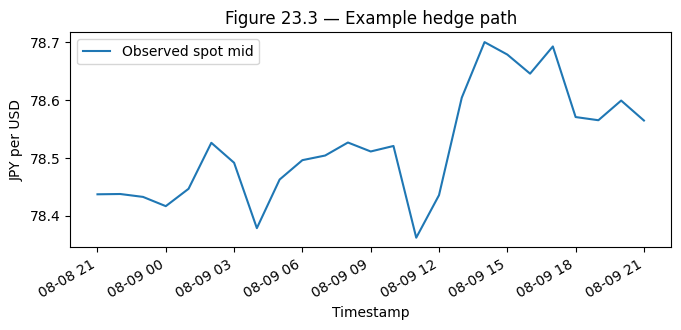

In [9]:
example = complete.loc[complete.application_stage.eq('DEVELOPMENT')].iloc[0]
example_fields = ['model_day', 'decision_boundary', 'actual_entry_timestamp', 'actual_expiry_timestamp', 'spot_entry_mid', 'strike', 'I_t_model', 'iv_raw_variance', 'iv_entry', 'maturity_years', 'call_premium', 'put_premium', 'straddle_premium']
display(example[example_fields].to_frame('value'))
example_ledger = ledger.loc[ledger.model_day.eq(example.model_day) & ledger.position_side.eq('LONG')]
display(pd.concat([example_ledger.head(4), example_ledger.tail(3)]).drop_duplicates())
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(example_ledger.timestamp, example_ledger.spot_mid, label='Observed spot mid')
ax.set(title='Figure 23.3 — Example hedge path', xlabel='Timestamp', ylabel='JPY per USD')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / '23_figure_example_hedge_path.png', dpi=180)
plt.show()

# 11. Economic mechanics diagnostics

These descriptive DEVELOPMENT and VALIDATION results show the mechanics of the synthetic contract only. They do not select a strategy, use hidden-event labels, or evaluate TEST outcomes.

,application_stage,n_complete,mean_straddle_premium,median_straddle_premium,mean_hedge_turnover,mean_spot_transaction_cost,median_spot_transaction_cost,mean_long_norm_mid,mean_long_norm_bidask
0,DEVELOPMENT,1048,0.508798,0.482933,3.518473,0.018196,0.014499,-0.088342,-0.126994
1,VALIDATION,961,0.328931,0.301894,3.719985,0.017552,0.012938,0.049772,-0.008006


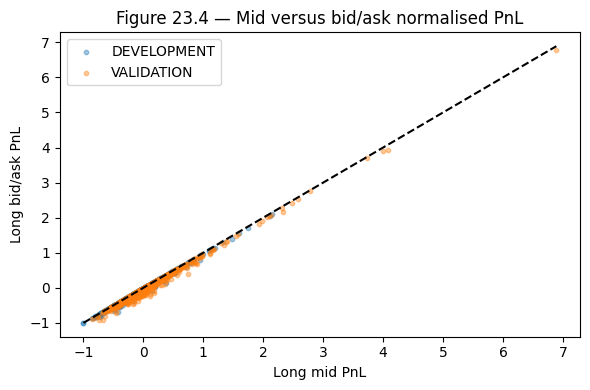

In [10]:
economic = complete.groupby('application_stage', as_index=False).agg(n_complete=('model_day', 'size'), mean_straddle_premium=('straddle_premium', 'mean'), median_straddle_premium=('straddle_premium', 'median'), mean_hedge_turnover=('long_hedge_turnover', 'mean'), mean_spot_transaction_cost=('long_spot_transaction_cost', 'mean'), median_spot_transaction_cost=('long_spot_transaction_cost', 'median'), mean_long_norm_mid=('long_pnl_norm_mid', 'mean'), mean_long_norm_bidask=('long_pnl_norm_bidask', 'mean'))
display(economic)
fig, ax = plt.subplots(figsize=(6, 4))
for stage, stage_rows in complete.groupby('application_stage'):
    ax.scatter(stage_rows.long_pnl_norm_mid, stage_rows.long_pnl_norm_bidask, s=10, alpha=0.4, label=stage)
plot_limits = [min(complete.long_pnl_norm_mid.min(), complete.long_pnl_norm_bidask.min()), max(complete.long_pnl_norm_mid.max(), complete.long_pnl_norm_bidask.max())]
ax.plot(plot_limits, plot_limits, 'k--')
ax.set(title='Figure 23.4 — Mid versus bid/ask normalised PnL', xlabel='Long mid PnL', ylabel='Long bid/ask PnL')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / '23_figure_mid_vs_bidask_pnl.png', dpi=180)
plt.show()

# 12. Locked TEST handoff

`UNLOCK_TEST_PNL = False` in the saved notebook. TEST identifiers remain for chronology, but no TEST future path is simulated: terminal spot, payoff, hedge PnL, total PnL, and normalised PnL remain missing; no TEST hedge ledger, economic summary, or figure is produced.

# 13. Limitations

**Synthetic option contract.** Premiums are model-valued rather than observed historical dealer premiums. **Raw ATM IV.** The raw Bloomberg ATM state is used, but its daily observation is not assigned a fabricated executable intraday quote timestamp. **ATM convention.** $$K=S_{0,\mathrm{mid}}$$ is a transparent spot-ATM assumption, not a recreation of proprietary dealer conventions. **Rates.** $$r_d=r_f=0$$ is a short-horizon simplification. **Option transaction costs.** Historical option bid/ask spreads are unavailable; observed spot bid/ask hedge costs are included. **Discrete hedging.** Hourly rebalancing leaves hedge error relative to continuous-time theory. **Incomplete paths.** Missing or market-closure paths are excluded under fixed quality rules rather than interpolated. The output is an economically interpretable translation of the realised--implied problem, not dealer-grade executable historical PnL.

# 14. Closure and exports

All final assertions must pass before the five canonical production exports are atomically replaced.

In [11]:
assert UNLOCK_TEST_PNL is False and len(panel) == 3627 and panel.model_day.is_unique
complete_mask = panel.contract_complete
test_mask = panel.application_stage.eq('TEST')
assert panel.loc[test_mask, 'pnl_unlocked'].eq(False).all() and panel.loc[test_mask, 'exclusion_reason'].eq('TEST_PNL_LOCKED').all()
future = ['terminal_spot', 'option_payoff', 'long_pnl_mid', 'long_pnl_bidask', 'long_pnl_norm_mid', 'long_pnl_norm_bidask', 'short_pnl_mid', 'short_pnl_bidask', 'short_pnl_norm_mid', 'short_pnl_norm_bidask', 'long_spot_transaction_cost', 'short_spot_transaction_cost']
assert panel.loc[test_mask, future].isna().all().all() and ledger.application_stage.ne('TEST').all()
assert panel.loc[complete_mask, 'decision_boundary'].le(panel.loc[complete_mask, 'actual_entry_timestamp']).all()
assert panel.loc[complete_mask, 'actual_entry_timestamp'].lt(panel.loc[complete_mask, 'actual_expiry_timestamp']).all()
assert panel.loc[complete_mask, 'actual_expiry_timestamp'].le(panel.loc[complete_mask, 'scheduled_expiry_boundary']).all()
assert set(ledger['timestamp']).issubset(set(pretest_quotes['timestamp']))
assert panel.loc[complete_mask, 'entry_delay_hours'].between(0, MAX_ENTRY_DELAY_HOURS).all()
assert panel.loc[complete_mask, 'expiry_lead_hours'].between(0, MAX_EXPIRY_LEAD_HOURS).all()
assert panel.loc[complete_mask, 'n_hedge_observations'].ge(MIN_HEDGE_OBSERVATIONS).all()
assert panel.loc[complete_mask, 'max_quote_gap_hours'].le(MAX_INTERIOR_QUOTE_GAP_HOURS).all()
assert np.allclose(panel.loc[complete_mask, 'strike'], panel.loc[complete_mask, 'spot_entry_mid'], atol=TOL, rtol=0)
assert np.allclose(panel.loc[complete_mask, 'iv_entry'], np.sqrt(panel.loc[complete_mask, 'iv_raw_variance']), atol=1e-14, rtol=0)
contract_iv_range = ledger.groupby(['model_day', 'position_side'])['contract_iv'].agg(lambda x: x.max() - x.min())
assert contract_iv_range.le(1e-14).all()
assert 'I_t_model' not in ledger.columns
assert np.allclose(panel.loc[complete_mask, 'short_pnl_mid'], -panel.loc[complete_mask, 'long_pnl_mid'], atol=TOL, rtol=0)
assert panel.loc[complete_mask, 'long_spot_transaction_cost'].ge(-TOL).all() and panel.loc[complete_mask, 'short_spot_transaction_cost'].ge(-TOL).all()
assert unit_tests.passed.all()
assert unit_tests['passed'].all()
closure = pd.DataFrame([('N22 integrity', True), ('unit tests', bool(unit_tests.passed.all())), ('no interpolation', bool(set(ledger['timestamp']).issubset(set(pretest_quotes['timestamp'])))), ('fixed entry IV', bool(contract_iv_range.le(1e-14).all())), ('TEST PnL lock', True), ('no TEST ledger', True)], columns=['check', 'passed'])
display(closure)
assert closure.passed.all()
ready = True
print('N23 closure: PASS')

,check,passed
0,N22 integrity,True
1,unit tests,True
2,no interpolation,True
3,fixed entry IV,True
4,TEST PnL lock,True
5,no TEST ledger,True


N23 closure: PASS


In [12]:
if not ready:
    raise RuntimeError('Closure must pass before export')
metadata = pd.DataFrame([{'notebook': '23_application_option_contract_and_pnl_engine.ipynb', 'execution_timestamp_utc': datetime.now(timezone.utc).isoformat(), 'input_n22_file': '22_application_causal_state_panel.csv', 'causal_iv_source': 'N22 weekday-normalised I_t_model', 'economic_option_iv_source': 'daily panel implied_vol_decimal', 'pricing_volatility_convention': 'RAW_BLOOMBERG_ATM_DECIMAL', 'hourly_spot_source': 'audited mid plus exact timestamp bid/ask closes', 'timezone': NY_ZONE, 'decision_boundary': '17:00 NY decision boundary, not observed option quote', 'entry_rule': 'first quote at/after boundary within 2 hours', 'expiry_rule': 'last quote at/before next boundary within 2 hours', 'strike_convention': 'SPOT_ATM', 'notional_usd': 1, 'pricing_model': 'GARMAN_KOHLHAGEN', 'rates': 'r_d=r_f=0', 'hedge_volatility': 'ENTRY_RAW_ATM_IV_FIXED', 'option_costs': 'UNAVAILABLE_EXCLUDED', 'spot_costs': 'OBSERVED_BID_ASK', 'test_pnl_unlocked': False, 'interpolation_used': False}])
exports = {'23_application_option_pnl_panel.csv': panel, '23_application_hedge_ledger.csv': ledger, '23_contract_coverage_summary.csv': coverage, '23_contract_unit_tests.csv': unit_tests, '23_run_metadata.csv': metadata}
temps = {}
for name, frame in exports.items():
    temps[name] = PROCESSED / f'.{name}.tmp'
    frame.to_csv(temps[name], index=False)
for name, temp in temps.items():
    temp.replace(PROCESSED / name)
print('N23 exports written:', ', '.join(exports))

N23 exports written: 23_application_option_pnl_panel.csv, 23_application_hedge_ledger.csv, 23_contract_coverage_summary.csv, 23_contract_unit_tests.csv, 23_run_metadata.csv
